In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])

# Increase fonts globally (adjust sizes as needed)
# DEFAULT IS 12
plt.rcParams.update({
    'font.size': 15,            # default text size
    'axes.titlesize': 15,      # axes title
    'axes.labelsize': 15,      # x/y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend text
    'figure.titlesize': 15
})

from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

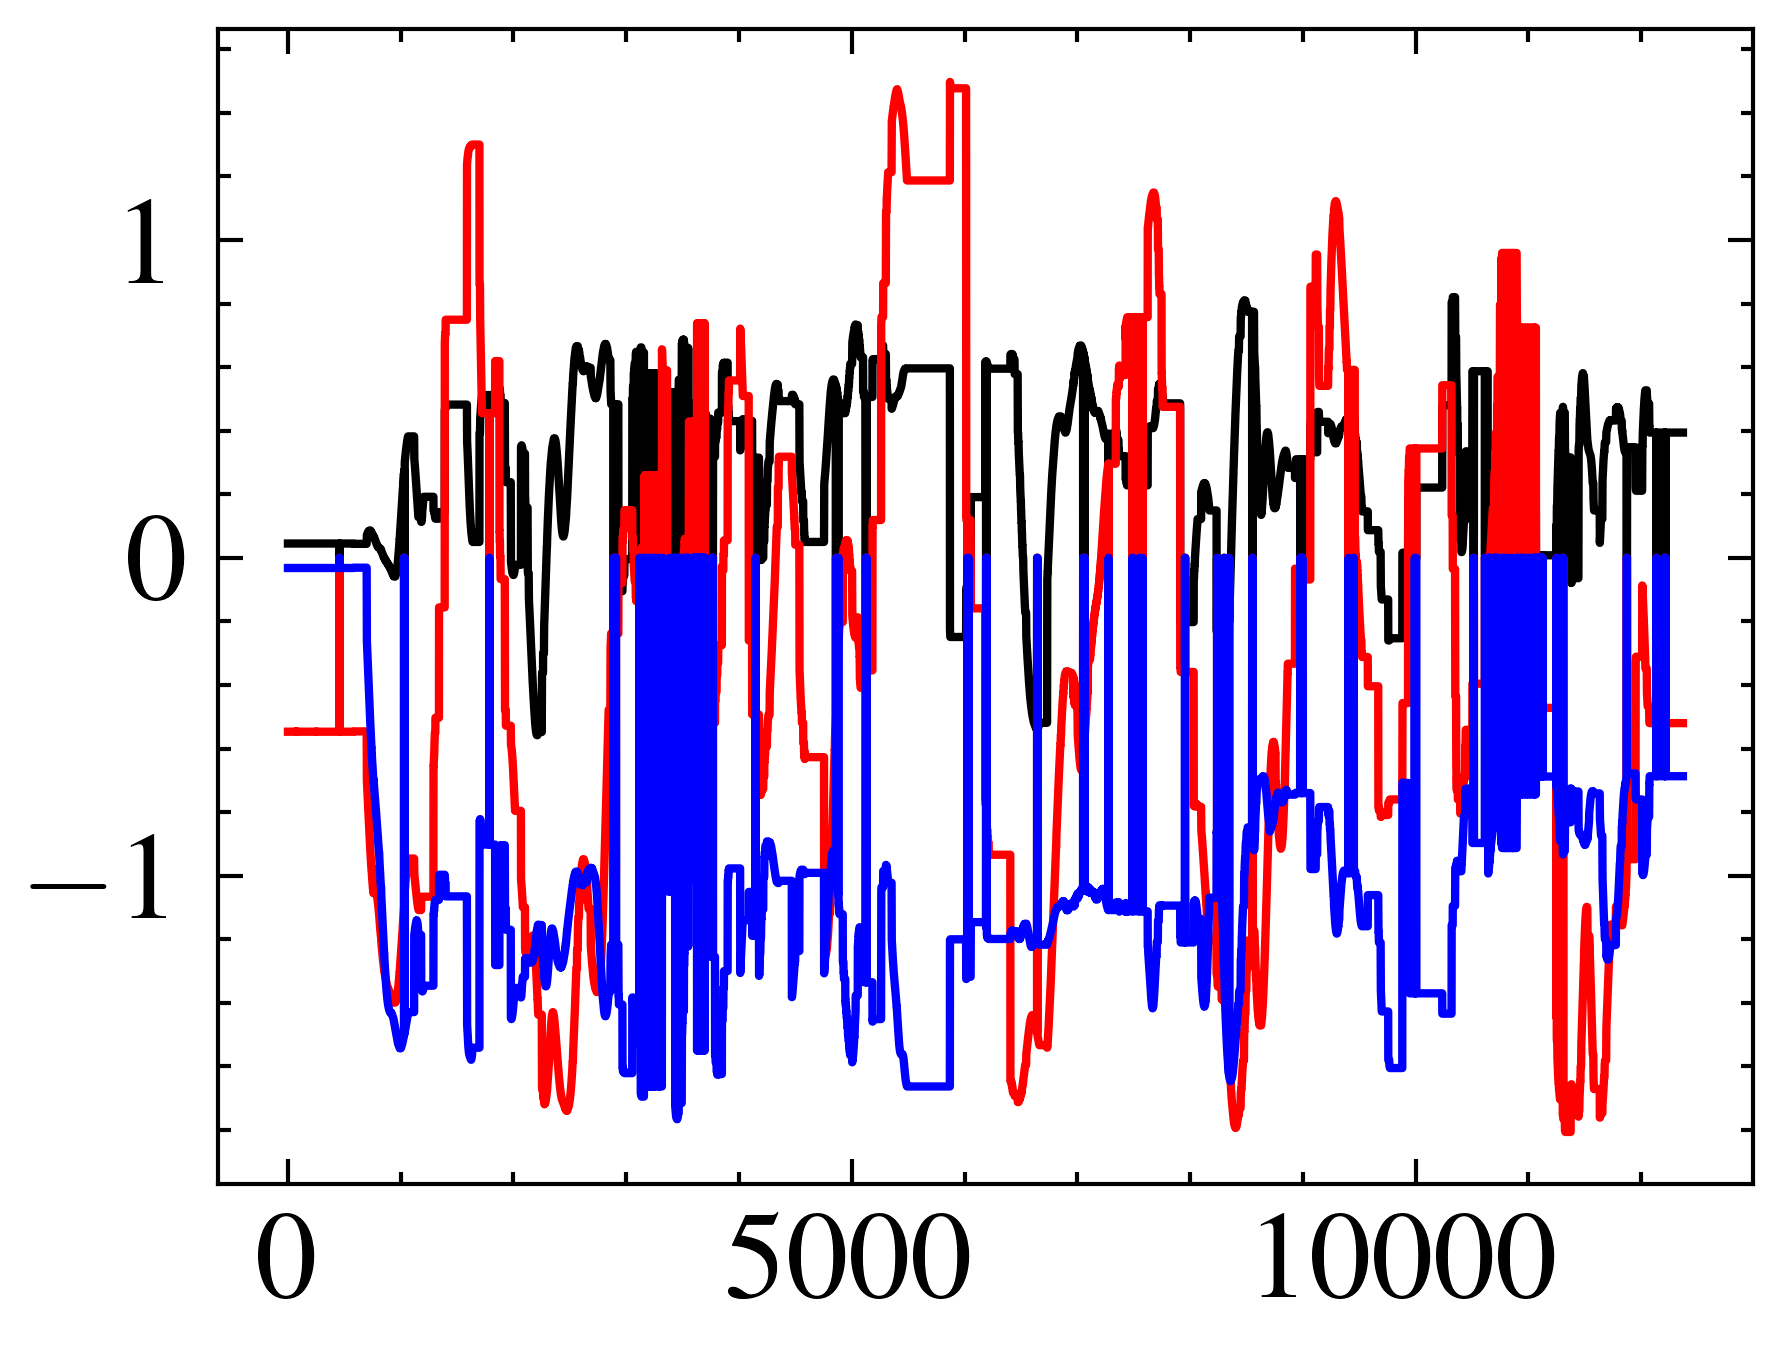

In [2]:
### Plotting checksum related data for final paper ###

# Load tab-delimited file
# df = pd.read_csv('moving_in_circles.txt', delimiter='\t', header=None)
df = pd.read_csv('../Xbee_Arduino_Data_Capture_Tests/position_checksum_test_1.txt', delimiter='\t', header=None)
df.columns = ['timestamp_ms', 'x', 'y', 'z', 'valid']

# Extract as NumPy arrays
t = (1/1000) * df['timestamp_ms'].to_numpy()
x = df['x'].to_numpy()
y = df['y'].to_numpy()
z = -df['z'].to_numpy() # Convert to Down axis
valid = df['valid'].to_numpy()

# Plot raw data with index from 0 to 1
plt.figure()
plt.plot(x, '-')
plt.plot(y, '-')
plt.plot(z, '-')
plt.show()

# Take subset of data for plotting
subset_idx = slice(7800, 9900)  # Adjust slice as needed
t = t[subset_idx]
x = x[subset_idx]
y = y[subset_idx]
z = z[subset_idx]
valid = valid[subset_idx]

In [3]:
# # Test plotting of position data
# plt.figure()
# plt.plot(t, x, linestyle='-', label='x')
# plt.plot(t,y, linestyle='-', label='y')
# plt.plot(t,z, linestyle='-', label='z')
# plt.xlabel('Time (s)')
# plt.ylabel('Position (m)')
# plt.title("Position data")
# plt.legend()
# plt.savefig("raw_without_checksum_1.pdf", bbox_inches='tight')
# plt.show()

# # Calculating frequency at which data is received
# est_freq = 1 / np.mean(np.diff(t))  # in Hz
# # Printing estimated frequency
# print(f"Estimated Frequency: {est_freq} Hz")

# # Plot validity of data
# plt.figure()
# plt.plot(t, valid, label='validity')
# plt.title("Validity of data over time")
# plt.xlabel("Time (s)")
# plt.ylabel("Validity")
# plt.legend(loc=(1.01, 0.8))
# plt.savefig("checksum_validity_1.pdf", bbox_inches='tight')
# plt.show()

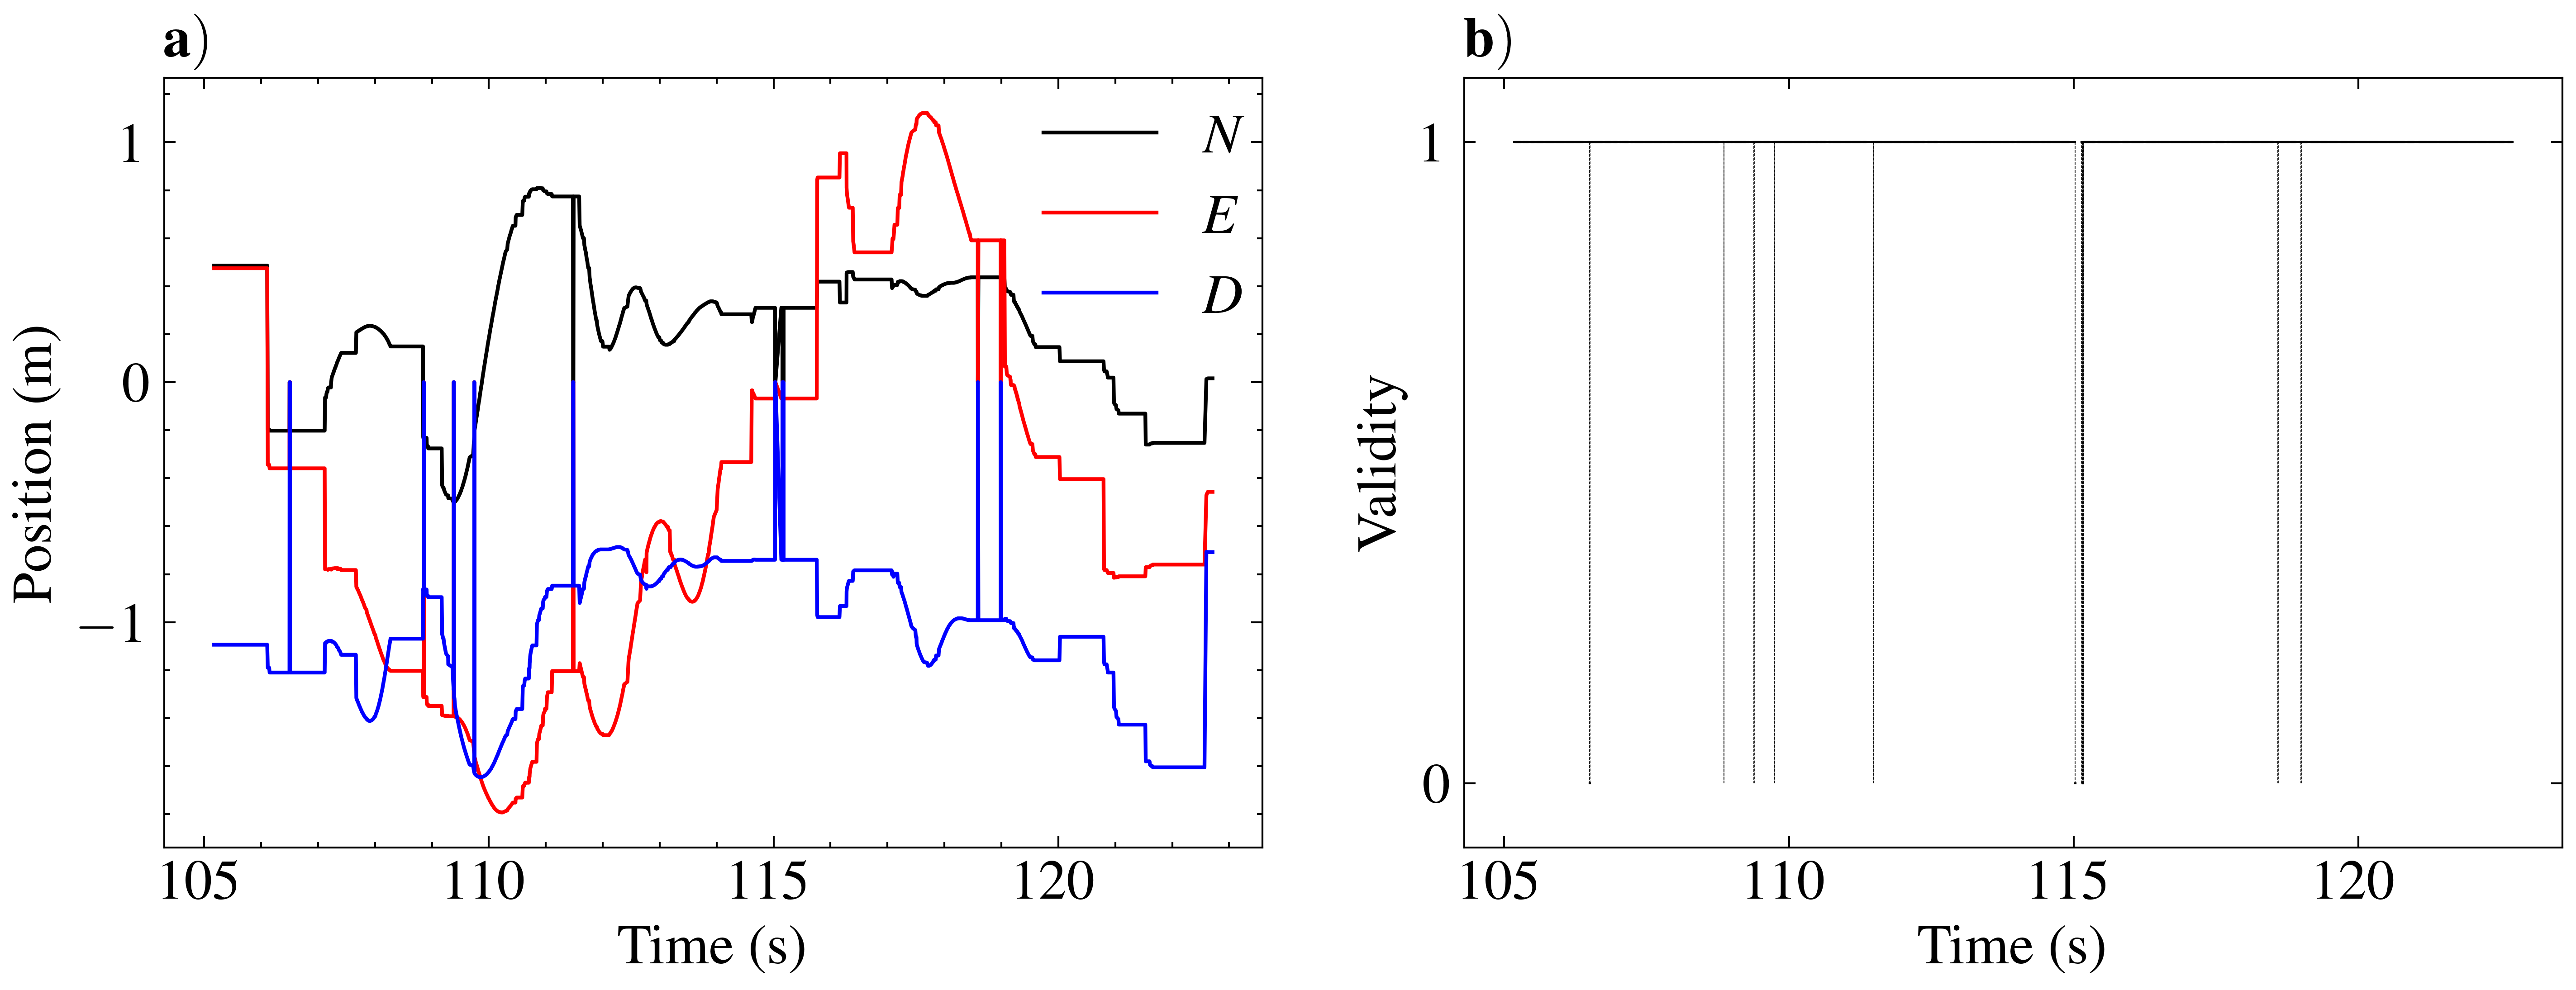

In [8]:
# Plot raw and validity in a subplot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t, x, linestyle='-', label='$N$')
plt.plot(t, y, linestyle='-', label='$E$')
plt.plot(t, z, linestyle='-', label='$D$')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title(r'$\bf{a)}$', loc='left')
plt.legend(loc=(0.78, 0.65))
ax = plt.subplot(1,2,2)
# Plot horizontal lines
# ax.plot(t, valid, 'k-', label='validity', drawstyle='steps-post', linewidth=0.8)
# Add vertical dashed lines at transitions
for i in range(1, len(t)):
    if valid[i] != valid[i-1]:
        ax.plot([t[i], t[i]], [valid[i-1], valid[i]], 'k--', linewidth=0.2)
    else:
        ax.plot([t[i-1], t[i]], [valid[i], valid[i]], 'k-', linewidth=0.5)
ax.set_title(r'$\bf{b)}$', loc='left')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Validity")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.minorticks_off()   # disable minor ticks so no tick lines appear between 0 and 1
# plt.legend(loc=(1.01, 0.8))
plt.tight_layout()
plt.savefig("raw_and_validity_1.pdf", bbox_inches='tight')
plt.show()

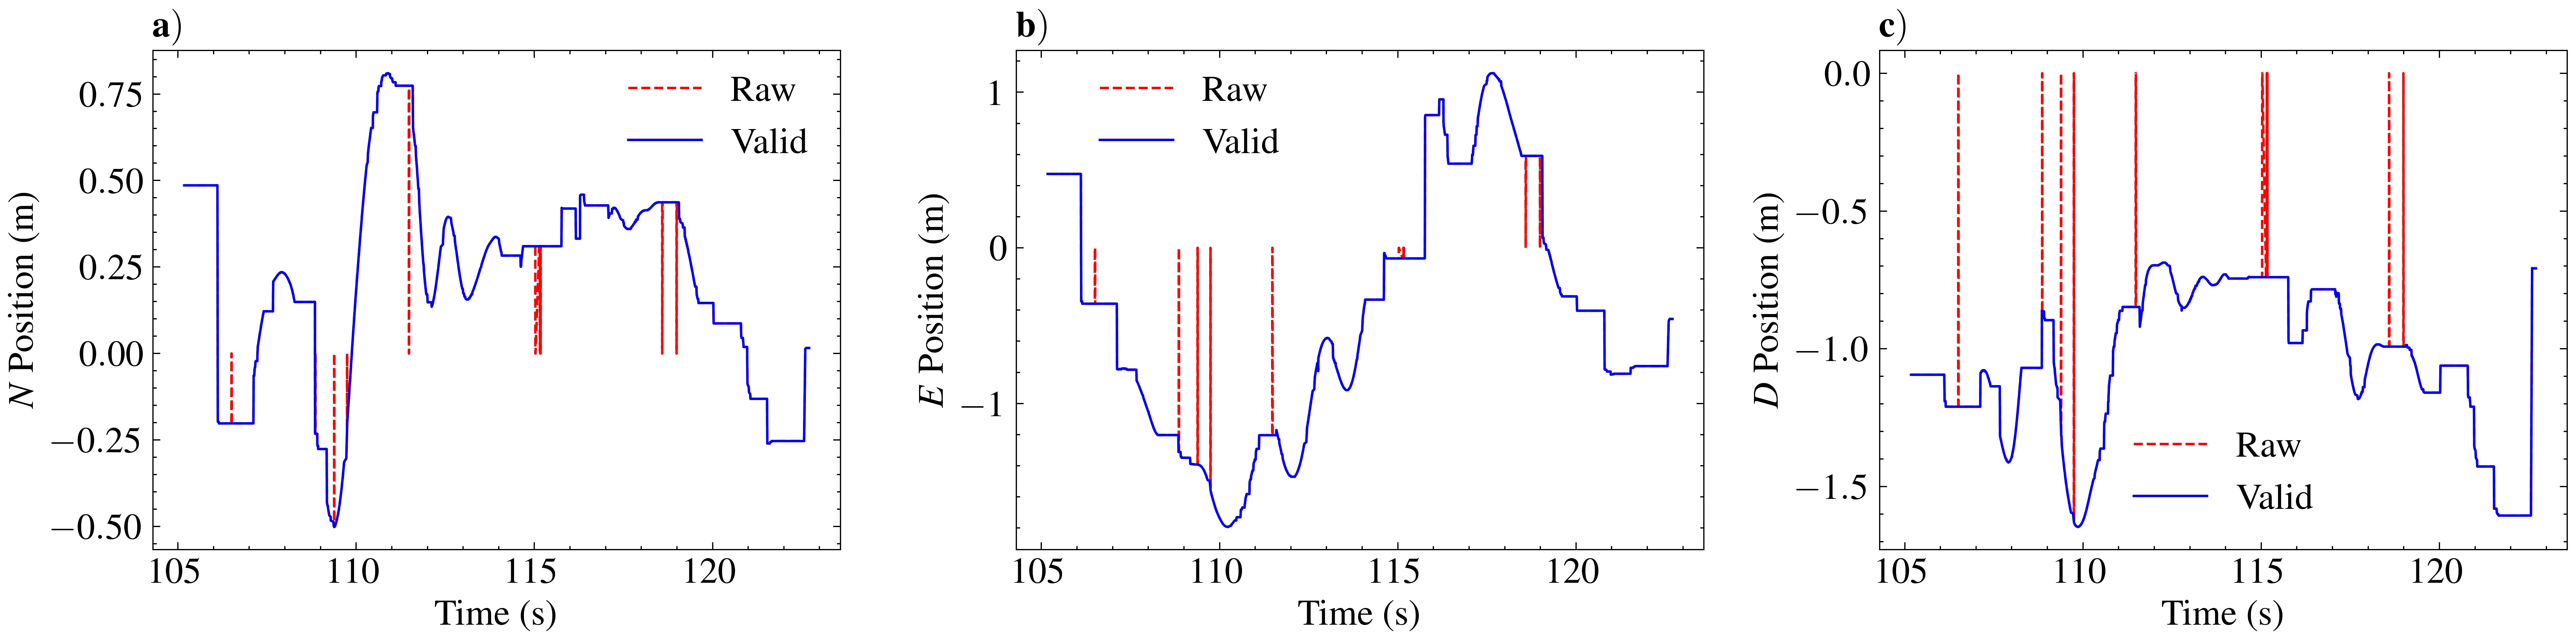

In [12]:
# Create new arrays for valid data only
t_valid = t[valid == 1]
x_valid = x[valid == 1]
y_valid = y[valid == 1]
z_valid = z[valid == 1]

# Plot invalid and valid data together for each axis, in a 1x3 subplot
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(t, x, 'r--', label='Raw')
plt.plot(t_valid, x_valid, 'b-', label='Valid')
plt.xlabel('Time (s)')
plt.ylabel('$N$ Position (m)')
plt.title(r'$\bf{a)}$', loc='left')
plt.legend(loc=(0.67,0.75))

plt.subplot(1,3,2)
plt.plot(t, y, 'r--', label='Raw')
plt.plot(t_valid, y_valid, 'b-', label='Valid')
plt.xlabel('Time (s)')
plt.ylabel('$E$ Position (m)')
plt.title(r'$\bf{b)}$', loc='left')
plt.legend(loc=(0.1,0.75))

plt.subplot(1,3,3)
plt.plot(t, z, 'r--', label='Raw')
plt.plot(t_valid, z_valid, 'b-', label='Valid')
plt.xlabel('Time (s)')
plt.ylabel('$D$ Position (m)')
plt.title(r'$\bf{c)}$', loc='left')
plt.legend(loc='best')

plt.tight_layout()
plt.savefig("valid_vs_invalid_1.pdf", bbox_inches='tight')
plt.show()

In [18]:
# Calculating frequency at which data is received
est_freq_raw = 1 / np.mean(np.diff(t))  # in Hz
est_freq_valid = 1 / np.mean(np.diff(t_valid))  # in Hz
# Printing estimated frequency
print(f"Estimated Frequency:\nRaw = {est_freq_raw} Hz\nValid = {est_freq_valid} Hz")

# Calculate frequency reduction due to invalid data
freq_reduction = est_freq_raw - est_freq_valid
print(f"Frequency Reduction due to invalid data: {freq_reduction} Hz")
# Calculate frequency reduction as a percentage
freq_reduction_percent = (freq_reduction / est_freq_raw) * 100
print(f"Frequency Reduction Percentage: {freq_reduction_percent:.2f} %")

Estimated Frequency:
Raw = 119.7239333789642 Hz
Valid = 118.46908510152866 Hz
Frequency Reduction due to invalid data: 1.254848277435542 Hz
Frequency Reduction Percentage: 1.05 %
